In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

headings=['Age','Gender','Total Bilirubin','Direct Bilirubin','Alkaline Phosphotase','Alamine Aminotransferase','Aspartate Aminotransferase','Total Proteins','Albumin','Albumin and Globulin ratio','Target']
data=pd.read_csv("C:/Users/iamal/Downloads/PRCP-1007-LiverPatientPred.zip",names=headings)
data.head()

,Age,Gender,Total Bilirubin,Direct Bilirubin,Alkaline Phosphotase,Alamine Aminotransferase,Aspartate Aminotransferase,Total Proteins,Albumin,Albumin and Globulin ratio,Target
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total Bilirubin             583 non-null    float64
 3   Direct Bilirubin            583 non-null    float64
 4   Alkaline Phosphotase        583 non-null    int64  
 5   Alamine Aminotransferase    583 non-null    int64  
 6   Aspartate Aminotransferase  583 non-null    int64  
 7   Total Proteins              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin and Globulin ratio  579 non-null    float64
 10  Target                      583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


In [3]:
data.describe()

,Age,Total Bilirubin,Direct Bilirubin,Alkaline Phosphotase,Alamine Aminotransferase,Aspartate Aminotransferase,Total Proteins,Albumin,Albumin and Globulin ratio,Target
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,579.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.947064,1.286449
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.319592,0.452490
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


In [4]:
print(data["Target"].unique())

[1 2]


In [5]:
data.rename(columns={'Target':'Disease'},inplace=True)

In [6]:
data.isnull().sum()

Age                           0
Gender                        0
Total Bilirubin               0
Direct Bilirubin              0
Alkaline Phosphotase          0
Alamine Aminotransferase      0
Aspartate Aminotransferase    0
Total Proteins                0
Albumin                       0
Albumin and Globulin ratio    4
Disease                       0
dtype: int64

In [7]:
data['Albumin and Globulin ratio'].mean()

0.9470639032815197

In [8]:
data=data.fillna(0.9)

In [9]:
data.isnull().sum()

Age                           0
Gender                        0
Total Bilirubin               0
Direct Bilirubin              0
Alkaline Phosphotase          0
Alamine Aminotransferase      0
Aspartate Aminotransferase    0
Total Proteins                0
Albumin                       0
Albumin and Globulin ratio    0
Disease                       0
dtype: int64

Visualization part

Number of patients diagnosed with liver disease: 416
Number of patients not diagnosed with liver disease: 167


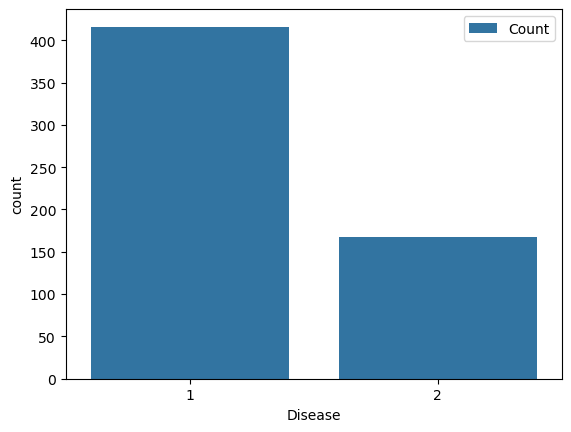

In [11]:
sns.countplot(data=data,x= 'Disease',label=('Count'))
LD,NLD=data['Disease'].value_counts()

print('Number of patients diagnosed with liver disease:',LD)
print('Number of patients not diagnosed with liver disease:',NLD)

Number of patients that are male: 441
Number of patients that are female: 142


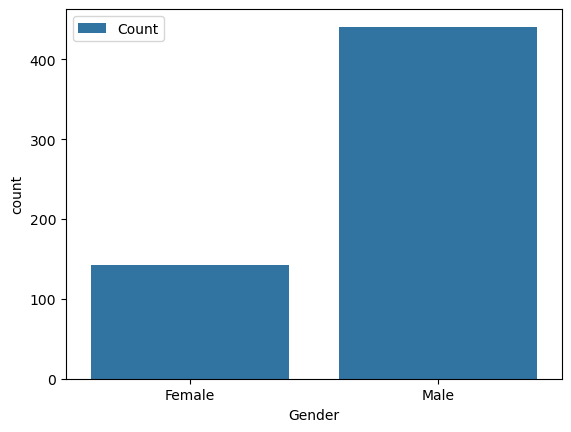

In [12]:
sns.countplot(data=data,x= 'Gender',label=('Count'))
M,F=data['Gender'].value_counts()

print('Number of patients that are male:',M)
print('Number of patients that are female:',F)

<Axes: xlabel='Gender', ylabel='count'>

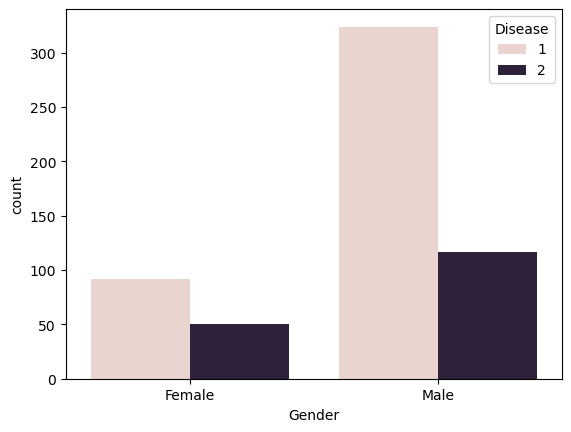

In [13]:

sns.countplot(x=data['Gender'],hue=data['Disease'])

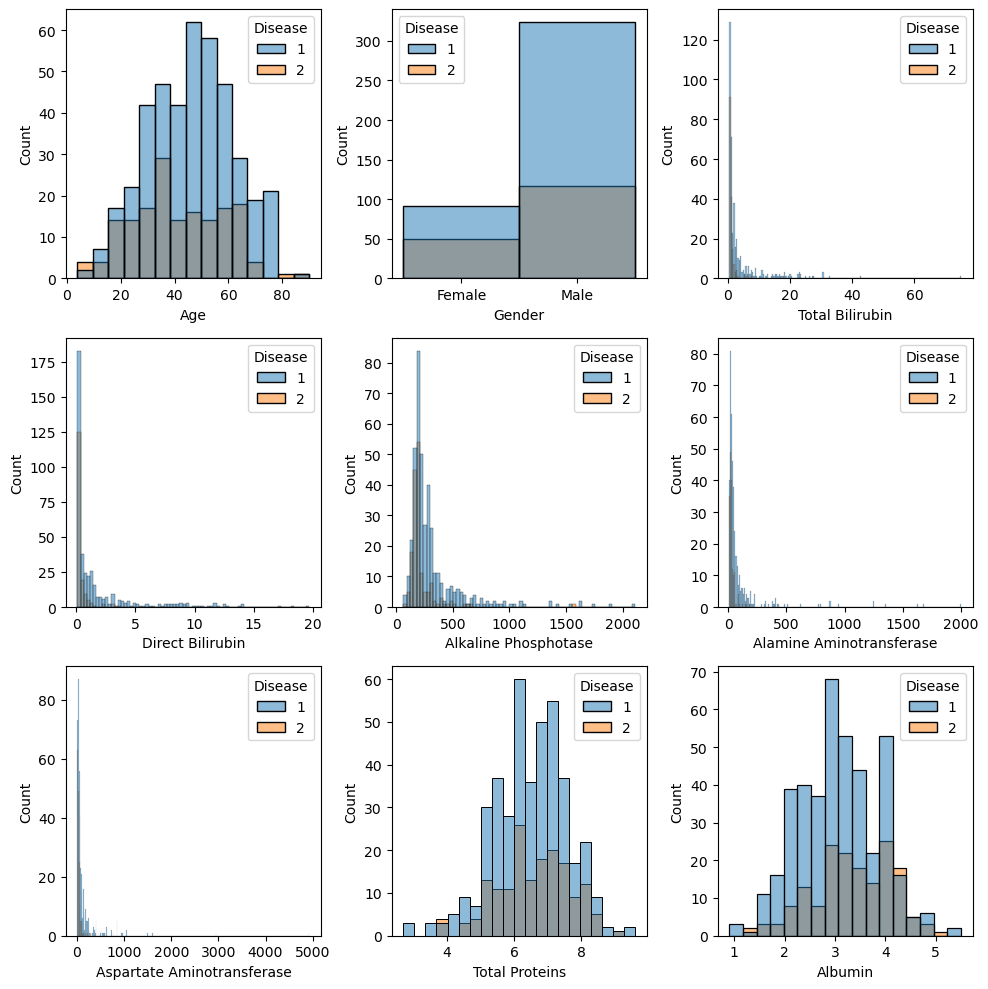

In [14]:
plt.figure(figsize=(10,10))
plot = 1

for i in data.drop('Disease',axis=1):
    if plot <= 9:
        ax = plt.subplot(3,3,plot)
        custom_colors = ['#1f77b4','#ff7f0e']
        sns.histplot(x=data[i],palette=custom_colors,hue=data['Disease'])
        plt.xlabel(i,fontsize=10)
    plot+=1
plt.tight_layout()
plt.show()

In [15]:
data[['Gender','Disease','Age']].groupby(['Disease','Gender'],as_index=False).count().sort_values(by='Disease',ascending=False)

,Disease,Gender,Age
2,2,Female,50
3,2,Male,117
0,1,Female,92
1,1,Male,324


In [16]:
data[['Gender','Disease','Age']].groupby(['Disease','Gender'],as_index=False).mean().sort_values(by='Disease',ascending=False)

,Disease,Gender,Age
2,2,Female,42.740000
3,2,Male,40.598291
0,1,Female,43.347826
1,1,Male,46.950617


There seems to be direct relationship between Total_Bilirubin and Direct_Bilirubin. We have the possibility of removing one of this feature.

there is a linear rs bw albumin and albumin globulion ratio 

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total Bilirubin             583 non-null    float64
 3   Direct Bilirubin            583 non-null    float64
 4   Alkaline Phosphotase        583 non-null    int64  
 5   Alamine Aminotransferase    583 non-null    int64  
 6   Aspartate Aminotransferase  583 non-null    int64  
 7   Total Proteins              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin and Globulin ratio  583 non-null    float64
 10  Disease                     583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


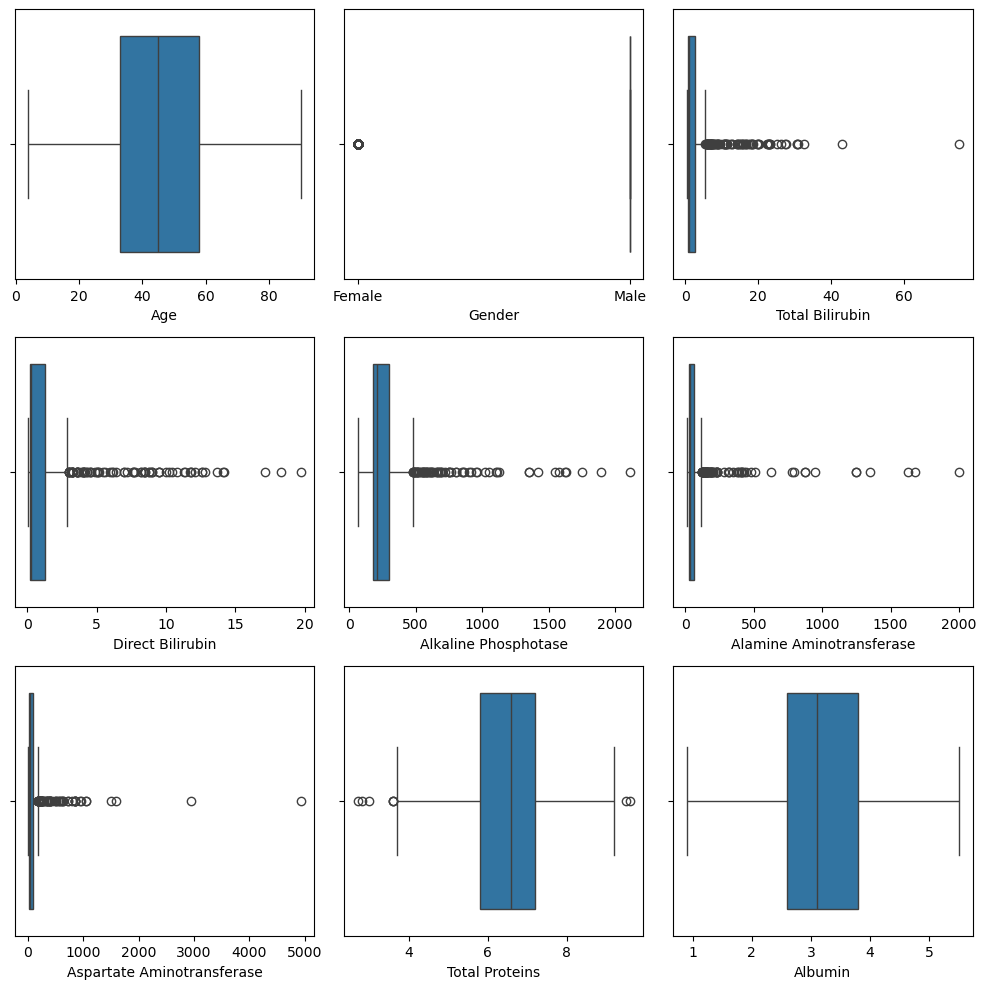

In [20]:
plt.figure(figsize=(10,10))
plotnumber = 1

for i in data.drop('Disease',axis=1):
    if plotnumber <= 9:
        ax = plt.subplot(3,3,plotnumber)
        sns.boxplot(x=data[i])
        plt.xlabel(i,fontsize=10)
    plotnumber +=1
plt.tight_layout()

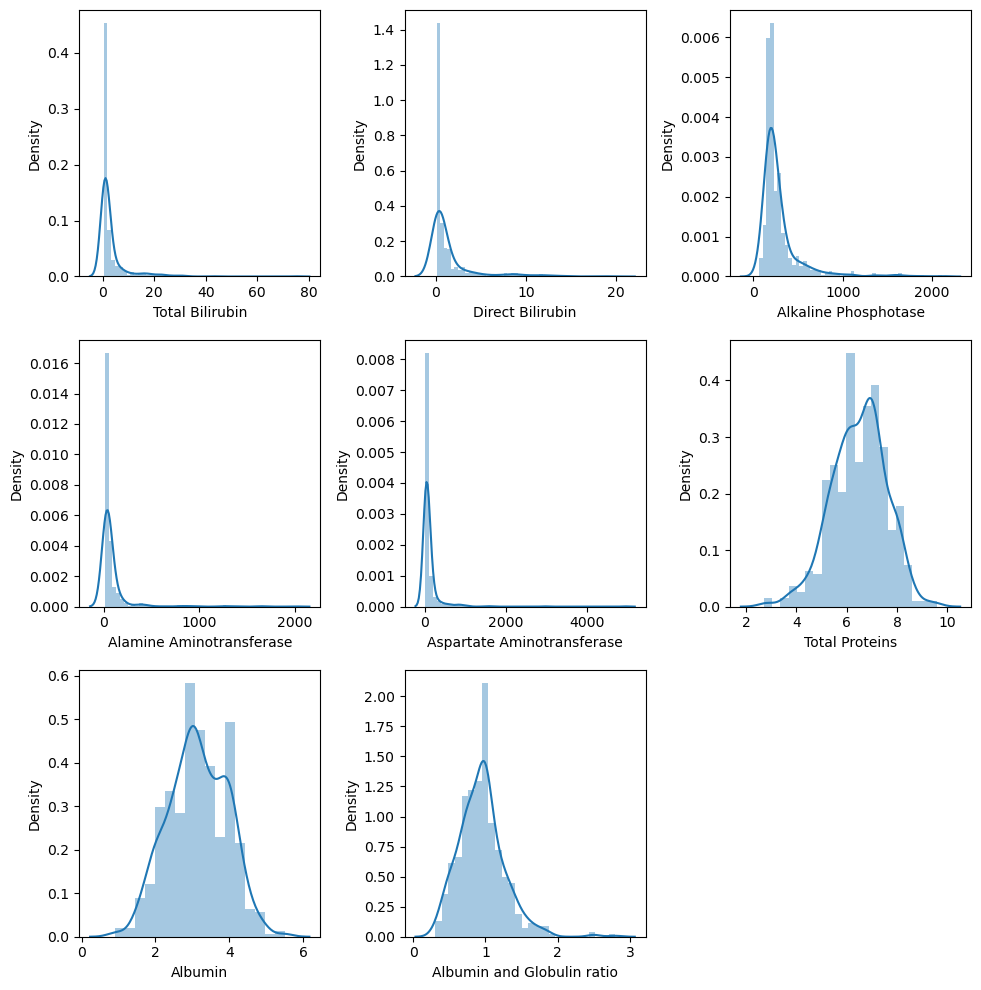

In [21]:
import warnings
warnings.filterwarnings('ignore')
plt.figure(figsize=(10,10))
plot = 1

for i in data.drop(columns=['Gender','Age','Disease'],axis=1):
    if plot <=9:
        ax = plt.subplot(3,3,plot)
        sns.distplot(data[i])
        plt.xlabel(i)
    plot+=1
plt.tight_layout()
plt.show()

<Axes: >

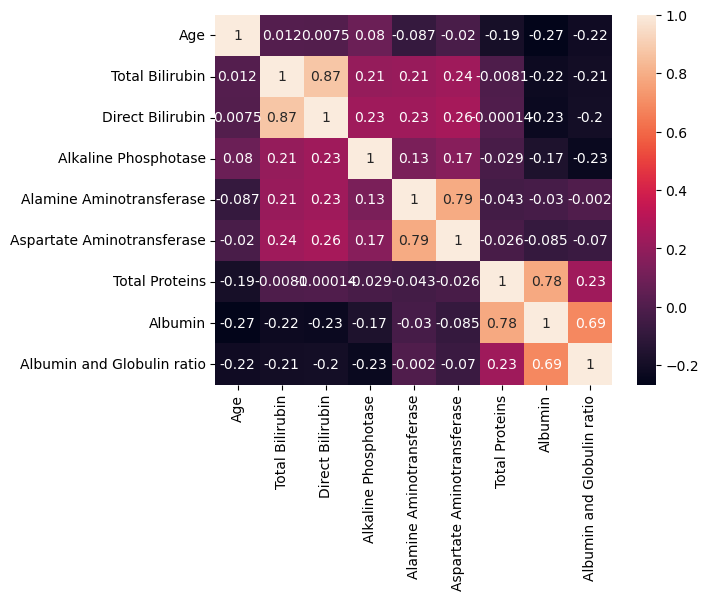

In [22]:
sns.heatmap(data.drop(columns=['Disease','Gender'],axis=1).corr(),annot=True)


In [23]:
data=data.drop('Direct Bilirubin',axis=1)

In [24]:
data.columns

Index(['Age', 'Gender', 'Total Bilirubin', 'Alkaline Phosphotase',
       'Alamine Aminotransferase', 'Aspartate Aminotransferase',
       'Total Proteins', 'Albumin', 'Albumin and Globulin ratio', 'Disease'],
      dtype='object')

In [25]:
data.describe()

,Age,Total Bilirubin,Alkaline Phosphotase,Alamine Aminotransferase,Aspartate Aminotransferase,Total Proteins,Albumin,Albumin and Globulin ratio,Disease
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000
mean,44.746141,3.298799,290.576329,80.713551,109.910806,6.483190,3.141852,0.946741,1.286449
std,16.189833,6.209522,242.937989,182.620356,288.918529,1.085451,0.795519,0.318516,0.452490
min,4.000000,0.400000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,0.800000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,208.000000,35.000000,42.000000,6.600000,3.100000,0.920000,1.000000
75%,58.000000,2.600000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


<Axes: xlabel='Total Bilirubin', ylabel='Density'>

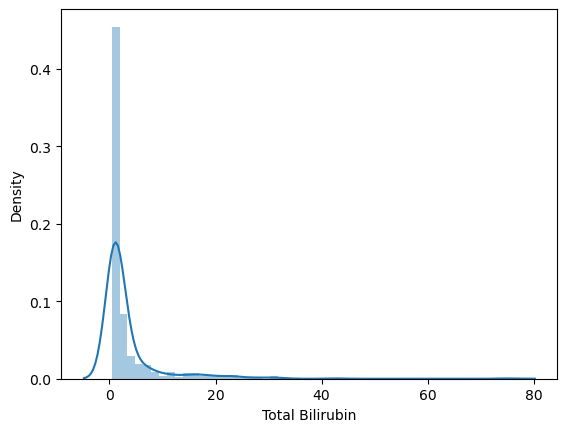

In [26]:
sns.distplot(data['Total Bilirubin'])

<Axes: xlabel='Total Bilirubin'>

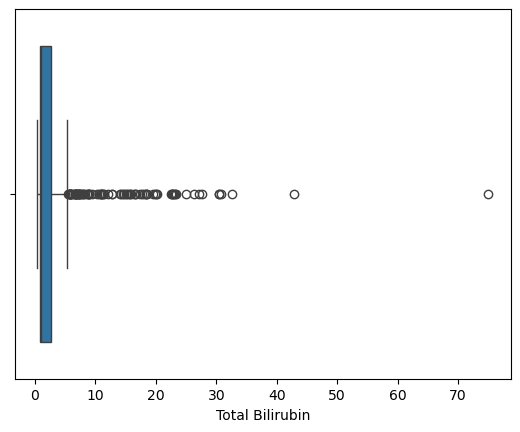

In [27]:
#to see outliers clearly
sns.boxplot(x=data['Total Bilirubin'])


In [28]:
data['Total Bilirubin'].mean()

3.298799313893653

## IQR method



In [30]:
q1=data['Total Bilirubin'].quantile(0.25)
q3=data['Total Bilirubin'].quantile(0.75)
iqr=q3-q1
q1,q3,iqr

(0.8, 2.6, 1.8)

In [31]:
upper=q3+(1.5*iqr)
lower=q1-(1.5*iqr)
lower,upper

(-1.9000000000000001, 5.300000000000001)

In [32]:
(len(data.loc[data['Total Bilirubin']>upper])/len(data))*100

14.408233276157805

<Axes: xlabel='Total Bilirubin'>

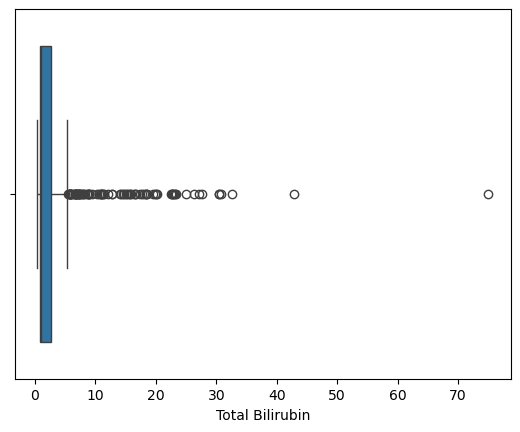

In [33]:
sns.boxplot(x=data['Total Bilirubin'])

In [34]:
#find outliers
(data.loc[(data['Total Bilirubin']>upper)|(data['Total Bilirubin']<lower)])

,Age,Gender,Total Bilirubin,Alkaline Phosphotase,Alamine Aminotransferase,Aspartate Aminotransferase,Total Proteins,Albumin,Albumin and Globulin ratio,Disease
1,62,Male,10.9,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,490,60,68,7.0,3.3,0.89,1
22,62,Male,6.8,542,116,66,6.4,3.1,0.90,1
27,34,Male,6.2,240,1680,850,7.2,4.0,1.20,1
37,46,Female,14.2,374,38,77,4.3,2.0,0.80,1
...,...,...,...,...,...,...,...,...,...,...
572,32,Male,15.6,134,54,125,5.6,4.0,2.50,1
574,32,Male,12.1,515,48,92,6.6,2.4,0.50,1
575,32,Male,25.0,560,41,88,7.9,2.5,2.50,1
576,32,Male,15.0,289,58,80,5.3,2.2,0.70,1


## trimming

In [36]:

new_data=data.loc[(data['Total Bilirubin']<upper)&(data['Total Bilirubin']>lower)]
print('before removing outliers:',len(data))
print('after removing outliers:',len(new_data))

before removing outliers: 583
after removing outliers: 499


## capping

In [38]:
new_data=data.copy()
new_data.loc[new_data['Total Bilirubin']>upper,'Total Bilirubin']=upper
new_data.loc[new_data['Total Bilirubin']<lower,'Total Bilirubin']=lower
len(new_data)

583

In [39]:
#Alkaline Phosphotase

<Axes: xlabel='Alkaline Phosphotase'>

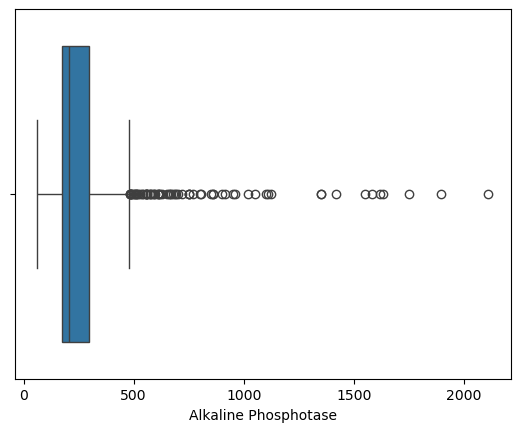

In [40]:
#to see outliers clearly
sns.boxplot(x=data['Alkaline Phosphotase'])

<Axes: xlabel='Alkaline Phosphotase', ylabel='Density'>

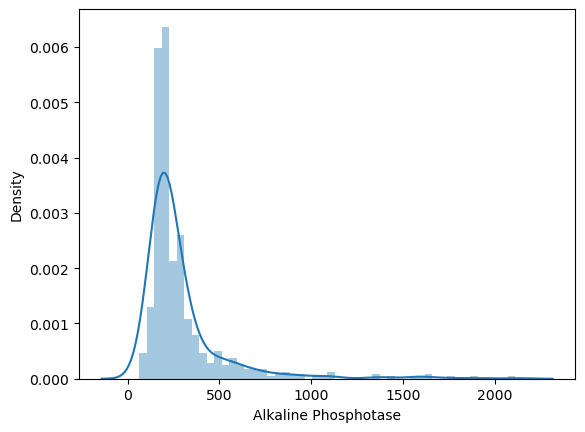

In [41]:
sns.distplot(data['Alkaline Phosphotase'])

## IOR

In [43]:
q1=data['Alkaline Phosphotase'].quantile(0.25)
q3=data['Alkaline Phosphotase'].quantile(0.75)
iqr=q3-q1
q1,q3,iqr

(175.5, 298.0, 122.5)

In [44]:
upper=q3+(1.5*iqr)
lower=q1-(1.5*iqr)
lower,upper

(-8.25, 481.75)

In [45]:
#find outliers
(data.loc[(data['Alkaline Phosphotase']>upper)|(data['Alkaline Phosphotase']<lower)])

,Age,Gender,Total Bilirubin,Alkaline Phosphotase,Alamine Aminotransferase,Aspartate Aminotransferase,Total Proteins,Albumin,Albumin and Globulin ratio,Disease
1,62,Male,10.9,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,490,60,68,7.0,3.3,0.89,1
20,51,Male,2.2,610,17,28,7.3,2.6,0.55,1
21,51,Male,2.9,482,22,34,7.0,2.4,0.50,1
22,62,Male,6.8,542,116,66,6.4,3.1,0.90,1
...,...,...,...,...,...,...,...,...,...,...
549,40,Female,2.1,768,74,141,7.8,4.9,1.60,1
573,32,Male,3.7,612,50,88,6.2,1.9,0.40,1
574,32,Male,12.1,515,48,92,6.6,2.4,0.50,1
575,32,Male,25.0,560,41,88,7.9,2.5,2.50,1


In [46]:
(len(data.loc[data['Alkaline Phosphotase']>upper])/len(data))*100

11.83533447684391

In [47]:
## trimming

In [48]:
new_data=data.loc[(data['Alkaline Phosphotase']<upper)&(data['Alkaline Phosphotase']>lower)]
print('before removing outliers:',len(data))
print('after removing outliers:',len(new_data))

before removing outliers: 583
after removing outliers: 514


In [49]:
## capping

In [50]:
new_data=data.copy()
new_data.loc[new_data['Alkaline Phosphotase']>upper,'Alkaline Phosphotase']=upper
new_data.loc[new_data['Alkaline Phosphotase']<lower,'Alkaline Phosphotase']=lower
len(new_data)

583

# Alamine Aminotransferase

<Axes: xlabel='Alamine Aminotransferase'>

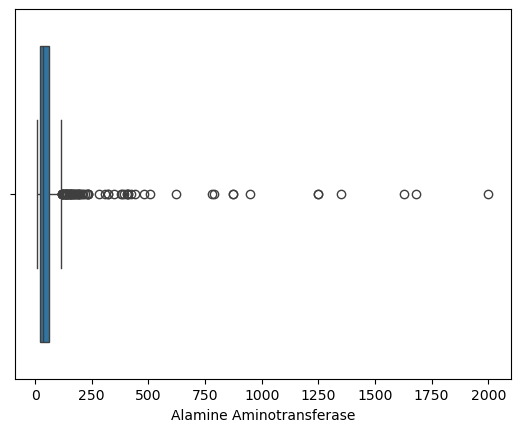

In [52]:
sns.boxplot(x=data['Alamine Aminotransferase'])

<Axes: xlabel='Alamine Aminotransferase', ylabel='Density'>

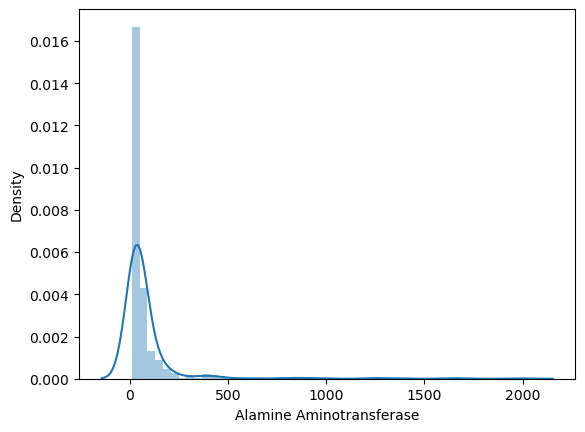

In [53]:
sns.distplot(data['Alamine Aminotransferase'])

### iqr

In [55]:
q1=data['Alamine Aminotransferase'].quantile(0.25)
q3=data['Alamine Aminotransferase'].quantile(0.75)
iqr=q3-q1
q1,q3,iqr

(23.0, 60.5, 37.5)

In [56]:
upper=q3+(1.5*iqr)
lower=q1-(1.5*iqr)
lower,upper

(-33.25, 116.75)

In [57]:
#find outliers
(data.loc[(data['Alamine Aminotransferase']>upper)|(data['Alamine Aminotransferase']<lower)])

,Age,Gender,Total Bilirubin,Alkaline Phosphotase,Alamine Aminotransferase,Aspartate Aminotransferase,Total Proteins,Albumin,Albumin and Globulin ratio,Disease
16,38,Male,1.8,342,168,441,7.6,4.4,1.3,1
18,40,Female,0.9,293,232,245,6.8,3.1,0.8,1
19,40,Female,0.9,293,232,245,6.8,3.1,0.8,1
25,34,Male,4.1,289,875,731,5.0,2.7,1.1,1
26,34,Male,4.1,289,875,731,5.0,2.7,1.1,1
...,...,...,...,...,...,...,...,...,...,...
560,66,Male,15.2,356,321,562,6.5,2.2,0.4,1
561,66,Male,16.6,315,233,384,6.9,2.0,0.4,1
562,66,Male,17.3,388,173,367,7.8,2.6,0.5,1
569,16,Male,7.7,268,213,168,7.1,4.0,1.2,1


In [58]:
(len(data.loc[data['Alamine Aminotransferase']>upper])/len(data))*100

12.521440823327614

In [59]:
# capping

In [60]:
new_data=data.copy()
new_data.loc[new_data['Alamine Aminotransferase']>upper,'Alamine Aminotransferase']=upper
new_data.loc[new_data['Alamine Aminotransferase']<lower,'Alamine Aminotransferase']=lower
len(new_data)

583

### Aspartate Aminotransferase

<Axes: xlabel='Aspartate Aminotransferase'>

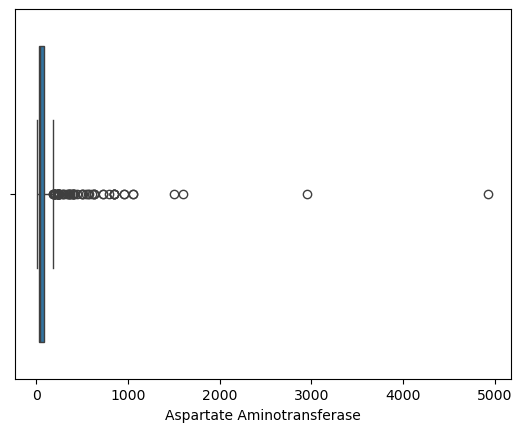

In [62]:
sns.boxplot(x=data['Aspartate Aminotransferase'])

<Axes: xlabel='Aspartate Aminotransferase', ylabel='Density'>

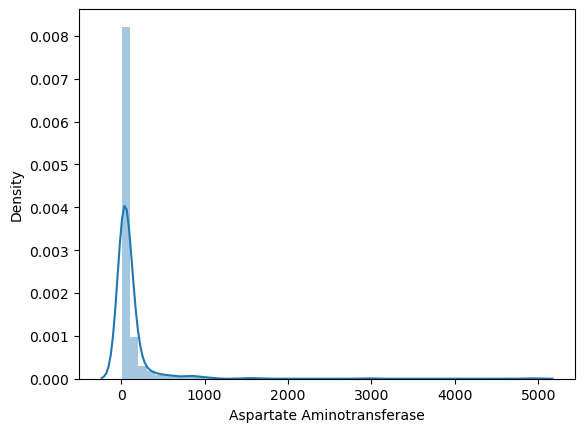

In [63]:
sns.distplot(data['Aspartate Aminotransferase'])

In [64]:
#iqr

In [65]:
q1=data['Aspartate Aminotransferase'].quantile(0.25)
q3=data['Aspartate Aminotransferase'].quantile(0.75)
iqr=q3-q1
q1,q3,iqr

(25.0, 87.0, 62.0)

In [66]:
upper=q3+(1.5*iqr)
lower=q1-(1.5*iqr)
lower,upper

(-68.0, 180.0)

In [67]:
#find outliers
(data.loc[(data['Aspartate Aminotransferase']>upper)|(data['Aspartate Aminotransferase']<lower)])

,Age,Gender,Total Bilirubin,Alkaline Phosphotase,Alamine Aminotransferase,Aspartate Aminotransferase,Total Proteins,Albumin,Albumin and Globulin ratio,Disease
16,38,Male,1.8,342,168,441,7.6,4.4,1.3,1
18,40,Female,0.9,293,232,245,6.8,3.1,0.8,1
19,40,Female,0.9,293,232,245,6.8,3.1,0.8,1
25,34,Male,4.1,289,875,731,5.0,2.7,1.1,1
26,34,Male,4.1,289,875,731,5.0,2.7,1.1,1
...,...,...,...,...,...,...,...,...,...,...
548,42,Male,11.1,214,60,186,6.9,2.8,2.8,1
558,51,Male,4.0,275,382,330,7.5,4.0,1.1,1
560,66,Male,15.2,356,321,562,6.5,2.2,0.4,1
561,66,Male,16.6,315,233,384,6.9,2.0,0.4,1


In [68]:
(len(data.loc[data['Aspartate Aminotransferase']>upper])/len(data))*100

11.320754716981133

In [69]:
#capping
new_data=data.copy()
new_data.loc[new_data['Aspartate Aminotransferase']>upper,'Aspartate Aminotransferase']=upper
new_data.loc[new_data['Aspartate Aminotransferase']<lower,'Aspartate Aminotransferase']=lower
len(new_data)

583

## Total Protein

<Axes: xlabel='Total Proteins'>

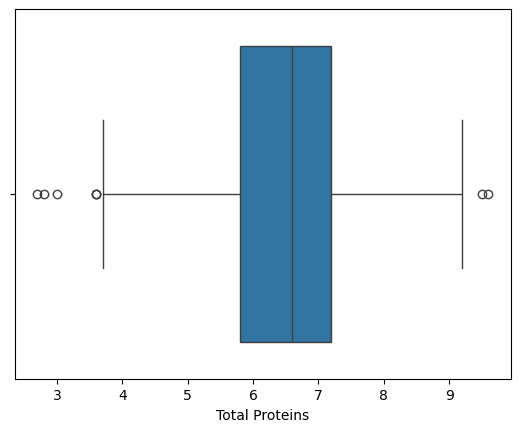

In [71]:
sns.boxplot(x=data['Total Proteins'])

<Axes: xlabel='Total Proteins', ylabel='Density'>

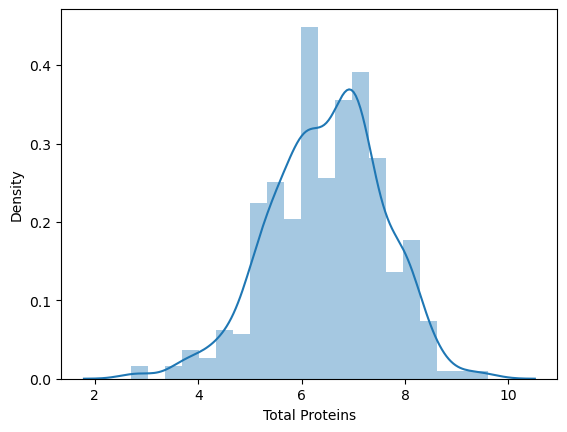

In [72]:
sns.distplot(data['Total Proteins'])

In [73]:
## z score


In [74]:
#z score
upper=data['Total Proteins'].mean()+3*data['Total Proteins'].std()
lower=data['Total Proteins'].mean()-3*data['Total Proteins'].std()
print('upper:',upper)
print('lower:',lower)

upper: 9.739544846581548
lower: 3.22683594244075


In [75]:
#find outliers
(data.loc[(data['Total Proteins']>upper)|(data['Total Proteins']<lower)])

,Age,Gender,Total Bilirubin,Alkaline Phosphotase,Alamine Aminotransferase,Aspartate Aminotransferase,Total Proteins,Albumin,Albumin and Globulin ratio,Disease
180,75,Male,2.8,250,23,29,2.7,0.9,0.5,1
181,75,Male,2.9,218,33,37,3.0,1.5,1.0,1
269,26,Male,0.6,110,15,20,2.8,1.6,1.3,1


In [76]:
(len(data.loc[data['Total Proteins']<lower])/len(data))*100

0.5145797598627788

In [77]:
(len(data.loc[data['Total Proteins']>upper])/len(data))*100

0.0

In [78]:
#trimming
new_data=data.loc[(data['Total Proteins']<upper)&(data['Total Proteins']>lower)]
print('before removing outliers:',len(data))
print('after removing outliers:',len(new_data))

before removing outliers: 583
after removing outliers: 580


## Albumin

<Axes: xlabel='Albumin'>

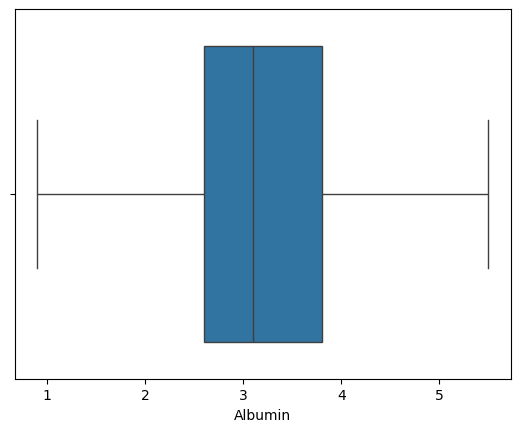

In [80]:
sns.boxplot(x=data['Albumin'])

<Axes: xlabel='Albumin', ylabel='Density'>

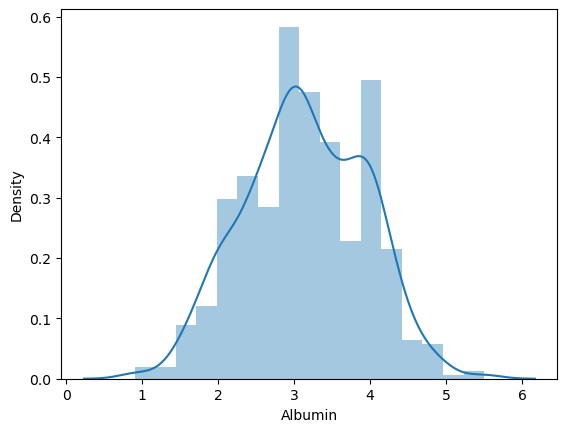

In [81]:
sns.distplot(data['Albumin'])


In [82]:
upper=data['Albumin'].mean()+3*data['Albumin'].std()
lower=data['Albumin'].mean()-3*data['Albumin'].std()
print('upper:',upper)
print('lower:',lower)

upper: 5.528408905027587
lower: 0.7552960692434247


In [83]:
#find outliers
(data.loc[(data['Albumin']>upper)|(data['Albumin']<lower)])

,Age,Gender,Total Bilirubin,Alkaline Phosphotase,Alamine Aminotransferase,Aspartate Aminotransferase,Total Proteins,Albumin,Albumin and Globulin ratio,Disease


In [84]:
## Albumin and Globumin ratio

<Axes: xlabel='Albumin and Globulin ratio'>

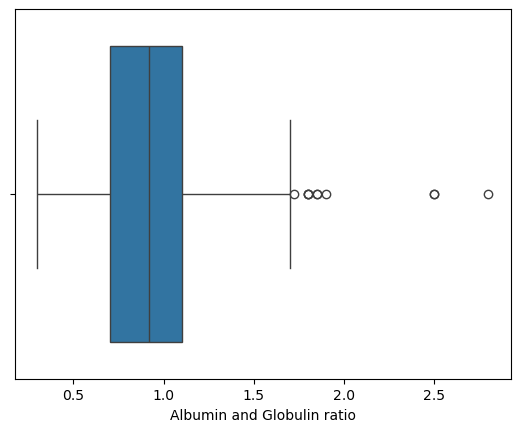

In [85]:
sns.boxplot(x=data['Albumin and Globulin ratio'])

<Axes: xlabel='Albumin and Globulin ratio', ylabel='Density'>

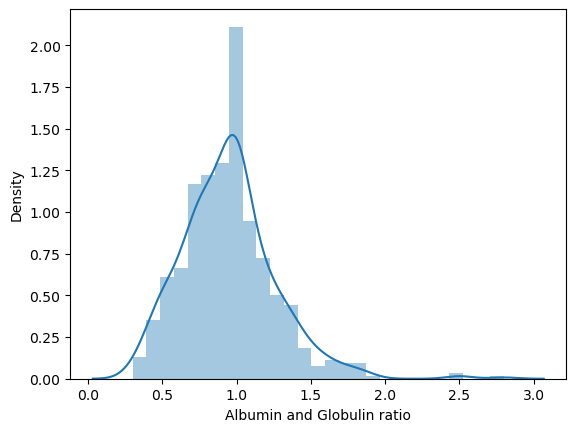

In [86]:
sns.distplot(data['Albumin and Globulin ratio'])

In [87]:
#iqr of albumin and globulin ratio

In [88]:
q1=data['Albumin and Globulin ratio'].quantile(0.25)
q3=data['Albumin and Globulin ratio'].quantile(0.75)
iqr=q3-q1
q1,q3,iqr

(0.7, 1.1, 0.40000000000000013)

In [89]:
upper=q3+(1.5*iqr)
lower=q1-(1.5*iqr)
lower,upper

(0.09999999999999976, 1.7000000000000002)

In [90]:
#find outliers
(data.loc[(data['Albumin and Globulin ratio']>upper)|(data['Albumin and Globulin ratio']<lower)])

,Age,Gender,Total Bilirubin,Alkaline Phosphotase,Alamine Aminotransferase,Aspartate Aminotransferase,Total Proteins,Albumin,Albumin and Globulin ratio,Disease
24,63,Male,0.9,194,52,45,6.0,3.9,1.85,2
215,66,Male,0.6,100,17,148,5.0,3.3,1.90,2
238,35,Female,0.9,190,40,35,7.3,4.7,1.80,2
243,28,Female,0.9,316,25,23,8.5,5.5,1.80,1
267,43,Female,0.9,140,12,29,7.4,3.5,1.80,1
484,62,Male,5.0,103,18,40,5.0,2.1,1.72,1
491,27,Male,1.0,180,56,111,6.8,3.9,1.85,2
548,42,Male,11.1,214,60,186,6.9,2.8,2.80,1
572,32,Male,15.6,134,54,125,5.6,4.0,2.50,1
575,32,Male,25.0,560,41,88,7.9,2.5,2.50,1


In [91]:
(len(data.loc[data['Albumin and Globulin ratio']>upper])/len(data))*100

1.7152658662092626

In [92]:
#trimming
new_data=data.loc[(data['Albumin and Globulin ratio']<upper)&(data['Albumin and Globulin ratio']>lower)]
print('before removing outliers:',len(data))
print('after removing outliers:',len(new_data))

before removing outliers: 583
after removing outliers: 573


In [93]:
data['Albumin and Globulin ratio'].describe()

count    583.000000
mean       0.946741
std        0.318516
min        0.300000
25%        0.700000
50%        0.920000
75%        1.100000
max        2.800000
Name: Albumin and Globulin ratio, dtype: float64

In [94]:
new_data['Albumin and Globulin ratio'].describe()

count    573.000000
mean       0.927452
std        0.281261
min        0.300000
25%        0.700000
50%        0.900000
75%        1.100000
max        1.700000
Name: Albumin and Globulin ratio, dtype: float64

<Axes: xlabel='Albumin and Globulin ratio', ylabel='Density'>

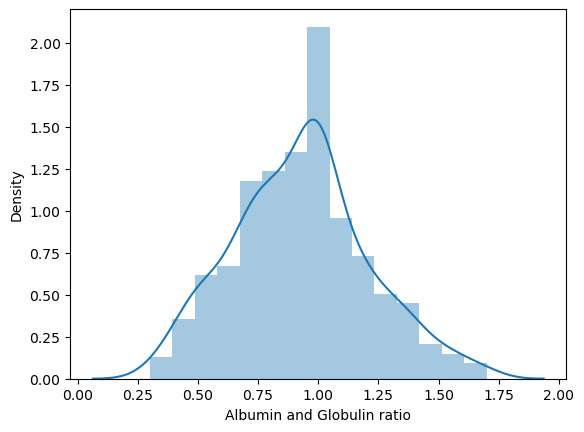

In [95]:
sns.distplot(new_data['Albumin and Globulin ratio'])

In [96]:
#IOR of total protiens

In [97]:
new_data.describe()

,Age,Total Bilirubin,Alkaline Phosphotase,Alamine Aminotransferase,Aspartate Aminotransferase,Total Proteins,Albumin,Albumin and Globulin ratio,Disease
count,573.000000,573.000000,573.000000,573.000000,573.000000,573.000000,573.000000,573.000000,573.000000
mean,44.776614,3.248342,291.928447,81.467714,110.380454,6.480454,3.133508,0.927452,1.284468
std,16.217458,6.161831,244.228735,184.105552,291.322434,1.084249,0.789614,0.281261,0.451555
min,4.000000,0.400000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,0.800000,176.000000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,209.000000,35.000000,42.000000,6.600000,3.100000,0.900000,1.000000
75%,58.000000,2.600000,298.000000,61.000000,86.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,1.700000,2.000000


In [98]:
data.describe()

,Age,Total Bilirubin,Alkaline Phosphotase,Alamine Aminotransferase,Aspartate Aminotransferase,Total Proteins,Albumin,Albumin and Globulin ratio,Disease
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000
mean,44.746141,3.298799,290.576329,80.713551,109.910806,6.483190,3.141852,0.946741,1.286449
std,16.189833,6.209522,242.937989,182.620356,288.918529,1.085451,0.795519,0.318516,0.452490
min,4.000000,0.400000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,0.800000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,208.000000,35.000000,42.000000,6.600000,3.100000,0.920000,1.000000
75%,58.000000,2.600000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


<Axes: >

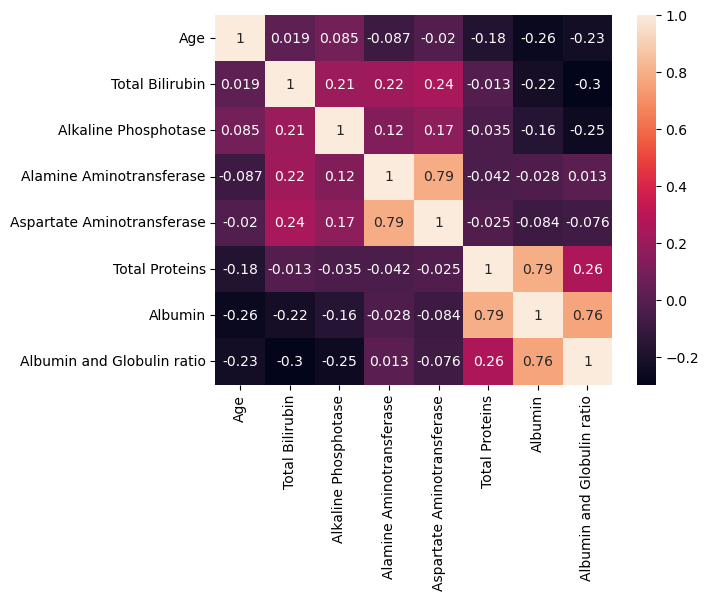

In [226]:

sns.heatmap(new_data.drop(['Disease','Gender'],axis=1).corr(),annot=True)